# No.1 [LO 1, LO 2, LO 3 & LO 4, 40% poin] Konsep sains data sebagai bidang studi sendiri diajukan oleh William S. Cleveland. Dia memperluas ilmu statistik ke area teknis, yang akan merubah bidang ini secara signifikan. Dia diminta untuk membuat sebuah aplikasi yang membantu perusahaan untuk memprediksi harga saham.
# Dalam dataset yang disediakan terdapat informasi penting mengenai keterangan setiap kolomnya. Yang akan digunakan kolom Date dan Close saja. Selanjutnya, pisahkan dataset terlebih dahulu menjadi data training dan data test, dengan data test mencakup periode satu tahun terakhir. Buatlah arsitektur Long Short Term Memory (LSTM). Berikut adalah ketentuan yang perlu diperhatikan dalam pembuatan arsitektur LSTM.
Video Presentasi:  https://drive.google.com/drive/folders/1QrVhhmqQCJuAX4GiaGiQDSW5Pp9wb_CK?usp=sharing

## 1a.[LO 3, LO 4, 5 poin] Lakukan eksplorasi data terlebih dahulu untuk memahami permasalahanyang dihadapi terlebih dahulu. Dataset yang diberikan adalah data time series, lakukan praproses data untuk menyelesaikan problem dari data tersebut. Pisahkan data time series tersebut menjadi dua bagian input dan output dengan window size = 5 [dari hari senin s.d jumat] dan horizon = 1 [hari senin saja]. Setelah itu, pisahkan data training menjadi train set dan validation set dengan proporsi 90% untuk train set dan 10% untuk validation set.


### EDA
yang perlu dilakukan:
1. Mengubah kolom Date ke format datetime
2. Menggunakan kolom Close sebagai target
3. Normalisasi data dengan MinMaxScaler agar nilai berada di rentang [0, 1]
4. Memisahkan data menjadi training set (sebelum 1 tahun terakhir) dan test set (1 tahun terakhir)
5. Membuat windowed dataset dengan window_size = 5 (Senin s.d. Jumat) dan horizon = 1 (hari Senin berikutnya)
6. Memisahkan training set menjadi 90% train dan 10% validation

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

TICKERS     = ['FB', 'IBM']
WINDOW_SIZE = 5
HORIZON     = 1
BATCH_SIZE  = 32

In [28]:
dfs = {}
for ticker in TICKERS:
    df = pd.read_csv(f'/kaggle/input/datasets/ernestintinn/dataset-uas/{ticker}.csv', parse_dates=['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    dfs[ticker] = df
    print(f'===Dataset {ticker}')
    print(f'Jumlah data: {len(df)} baris')
    print(f'Periode   : {df["Date"].min().date()} hingga {df["Date"].max().date()}')
    print(f'Kolom     : {list(df.columns)}')
    print()
    print(f'===Statistik Deskriptif Close ({ticker})')
    print(df[['Close']].describe().round(2))
    print()

===Dataset FB
Jumlah data: 1980 baris
Periode   : 2012-05-18 hingga 2020-04-01
Kolom     : ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

===Statistik Deskriptif Close (FB)
         Close
count  1980.00
mean    112.31
std      58.13
min      17.73
25%      64.76
50%     113.81
75%     168.09
max     223.23

===Dataset IBM
Jumlah data: 14663 baris
Periode   : 1962-01-02 hingga 2020-04-01
Kolom     : ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

===Statistik Deskriptif Close (IBM)
          Close
count  14663.00
mean      60.14
std       57.35
min        4.08
25%       16.11
50%       28.66
75%      102.31
max      215.80



FB memiliki data dari tahun 2012–2020 sebanyak 1.980 baris, sedangkan IBM memiliki data yang jauh lebih panjang yaitu 1962–2020 sebanyak 14.663 baris.
Harga penutupan kedua saham memiliki rentang nilai yang cukup lebar. FB berada pada kisaran 17,73–223,23 USD, sedangkan IBM berada pada kisaran 4,08–215,80 USD.
Nilai mean dan standar deviasi yang cukup besar menunjukkan bahwa harga saham mengalami perubahan yang cukup signifikan sepanjang periode pengamatan. Hal ini menandakan data memiliki tren sehingga perlu dilakukan normalisasi sebelum digunakan pada model LSTM.

### Visualisasi Harga Close & Volume 

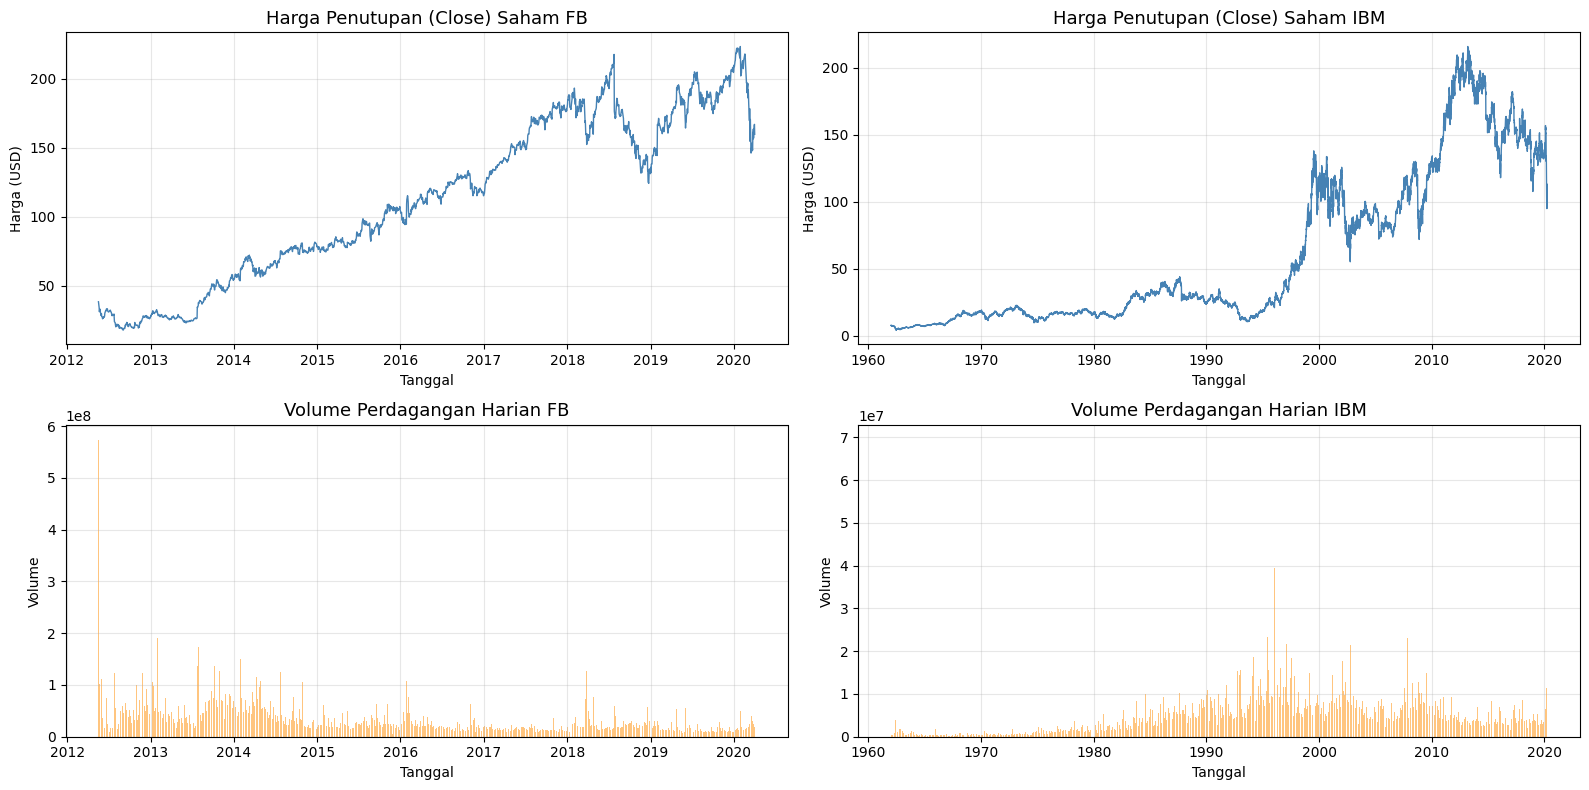

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for col, ticker in enumerate(TICKERS):
    df = dfs[ticker]
    axes[0, col].plot(df['Date'], df['Close'], color='steelblue', linewidth=1)
    axes[0, col].set_title(f'Harga Penutupan (Close) Saham {ticker}', fontsize=13)
    axes[0, col].set_xlabel('Tanggal')
    axes[0, col].set_ylabel('Harga (USD)')
    axes[0, col].grid(alpha=0.3)

    axes[1, col].bar(df['Date'], df['Volume'], color='darkorange', alpha=0.5, width=1)
    axes[1, col].set_title(f'Volume Perdagangan Harian {ticker}', fontsize=13)
    axes[1, col].set_xlabel('Tanggal')
    axes[1, col].set_ylabel('Volume')
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_close_volume.png', dpi=100, bbox_inches='tight')
plt.show()

Harga saham FB menunjukkan tren yang cenderung meningkat sejak mulai diperdagangkan pada tahun 2012, meskipun sempat mengalami penurunan pada beberapa periode. Harga saham IBM memiliki periode yang jauh lebih panjang dengan fluktuasi yang lebih besar. Terlihat beberapa fase kenaikan dan penurunan yang cukup signifikan sehingga pola pergerakannya lebih kompleks dibanding FB. Volume perdagangan kedua saham bersifat fluktuatif dengan beberapa lonjakan pada waktu tertentu yang menunjukkan adanya periode aktivitas transaksi yang lebih tinggi dibanding hari-hari biasa.

### Cek Missing Value & Duplikat

In [30]:
for ticker in TICKERS:
    df = dfs[ticker]
    print(f'Missing Values ({ticker})')
    print(df[['Date', 'Close']].isnull().sum())
    print(f'Duplikat tanggal: {df["Date"].duplicated().sum()}')

Missing Values (FB)
Date     0
Close    0
dtype: int64
Duplikat tanggal: 0
Missing Values (IBM)
Date     0
Close    0
dtype: int64
Duplikat tanggal: 0


Tidak ditemukan missing value maupun duplikasi tanggal pada kedua dataset. Dengan demikian, data sudah bersih sehingga tidak diperlukan proses imputasi maupun penghapusan data.

### Train Test Split

In [31]:
train_dfs = {}
test_dfs  = {}

for ticker in TICKERS:
    data_close  = dfs[ticker][['Date', 'Close']].copy()
    cutoff_date = data_close['Date'].max() - pd.DateOffset(years=1)
    train_dfs[ticker] = data_close[data_close['Date'] <= cutoff_date].copy()
    test_dfs[ticker]  = data_close[data_close['Date'] >  cutoff_date].copy()
    print(f'{ticker}')
    print(f'Cutoff date:{cutoff_date.date()}')
    print(f'Training set:{len(train_dfs[ticker])} data '
          f'({train_dfs[ticker]["Date"].min().date()} – {train_dfs[ticker]["Date"].max().date()})')
    print(f'Test set:{len(test_dfs[ticker])} data '
          f'({test_dfs[ticker]["Date"].min().date()} – {test_dfs[ticker]["Date"].max().date()})')

FB
Cutoff date:2019-04-01
Training set:1727 data (2012-05-18 – 2019-04-01)
Test set:253 data (2019-04-02 – 2020-04-01)
IBM
Cutoff date:2019-04-01
Training set:14410 data (1962-01-02 – 2019-04-01)
Test set:253 data (2019-04-02 – 2020-04-01)


Data dipisahkan secara kronologis, di mana seluruh data sebelum 1 tahun terakhir digunakan sebagai training set, sedangkan data pada 1 tahun terakhir digunakan sebagai test set sesuai dengan ketentuan soal. Pembagian dilakukan berdasarkan tanggal agar tidak terjadi data leakage dari masa depan ke masa lalu.

### Visualisasi Train Test Split

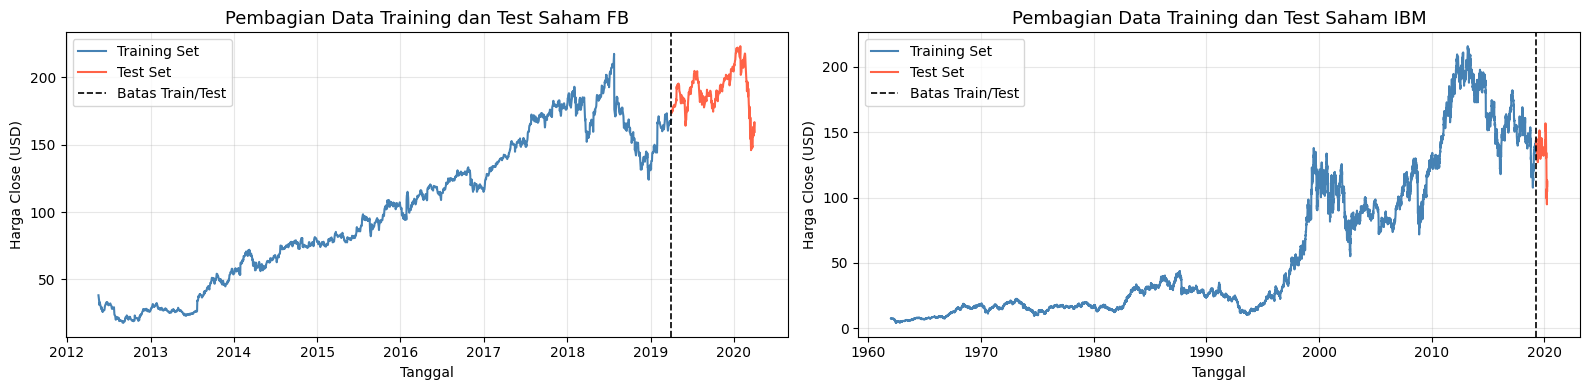

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, ticker in zip(axes, TICKERS):
    train_df = train_dfs[ticker]
    test_df  = test_dfs[ticker]
    cutoff_date = train_df['Date'].max()
    ax.plot(train_df['Date'], train_df['Close'], label='Training Set', color='steelblue')
    ax.plot(test_df['Date'],  test_df['Close'],  label='Test Set',     color='tomato')
    ax.axvline(x=cutoff_date, color='black', linestyle='--', linewidth=1.2, label='Batas Train/Test')
    ax.set_title(f'Pembagian Data Training dan Test Saham {ticker}', fontsize=13)
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Harga Close (USD)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=100, bbox_inches='tight')
plt.show()

Garis putus-putus menunjukkan batas antara data training dan data test sehingga model hanya mempelajari data historis sebelum melakukan prediksi pada periode berikutnya.

### Normalisasi Data
Harga saham dinormalisasi menggunakan MinMaxScaler ke rentang [0,1]. Proses fit scaler hanya dilakukan pada data training, kemudian scaler yang sama digunakan untuk mentransformasikan data test agar informasi dari data test tidak bocor ke proses pelatihan.

### Windowing Dataset
Data time series diubah menjadi supervised learning menggunakan window size = 5 dan horizon = 1. Model menggunakan harga 5 hari sebelumnya sebagai input untuk memprediksi harga pada 1 hari berikutnya.

Pada data test, lima data terakhir dari training digunakan sebagai seed window, jadi seluruh periode test tetap dapat diprediksi tanpa menggunakan informasi target dari data test.

In [33]:
def create_windowed_dataset(series, window_size=5, horizon=1):
    X, y = [], []
    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

store = {}
for ticker in TICKERS:
    train_df = train_dfs[ticker]
    test_df  = test_dfs[ticker]

    scaler       = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_df[['Close']].values)
    test_scaled  = scaler.transform(test_df[['Close']].values)

    print(f'{ticker} | Nilai min/max scaler : {scaler.data_min_[0]:.2f} / {scaler.data_max_[0]:.2f}')

    X_train_full, y_train_full = create_windowed_dataset(train_scaled.flatten(), WINDOW_SIZE, HORIZON)
    X_test, y_test = create_windowed_dataset(
        np.concatenate([train_scaled[-WINDOW_SIZE:].flatten(), test_scaled.flatten()]),
        WINDOW_SIZE, HORIZON
    )

    X_train_full = X_train_full.reshape(-1, WINDOW_SIZE, 1)
    X_test       = X_test.reshape(-1, WINDOW_SIZE, 1)

    print(f'  Window size : {WINDOW_SIZE}  |  Horizon : {HORIZON}')
    print(f'  X_train_full shape : {X_train_full.shape}   | y_train_full shape : {y_train_full.shape}')
    print(f'  X_test shape       : {X_test.shape}      | y_test shape       : {y_test.shape}')
    print()

    store[ticker] = {
        'scaler'       : scaler,
        'X_train_full' : X_train_full,
        'y_train_full' : y_train_full,
        'X_test'       : X_test,
        'y_test'       : y_test,
        'test_df'      : test_df,
    }

FB | Nilai min/max scaler : 17.73 / 217.50
  Window size : 5  |  Horizon : 1
  X_train_full shape : (1722, 5, 1)   | y_train_full shape : (1722,)
  X_test shape       : (253, 5, 1)      | y_test shape       : (253,)

IBM | Nilai min/max scaler : 4.08 / 215.80
  Window size : 5  |  Horizon : 1
  X_train_full shape : (14405, 5, 1)   | y_train_full shape : (14405,)
  X_test shape       : (253, 5, 1)      | y_test shape       : (253,)



Setelah proses windowing, data berubah menjadi bentuk tiga dimensi dengan format (jumlah sampel, window size, jumlah fitur) yang sesuai sebagai masukan model LSTM. Jumlah sampel berkurang sebesar ukuran window karena beberapa data awal digunakan sebagai input pertama.

### Train Validation Split

In [34]:
for ticker in TICKERS:
    d = store[ticker]
    X_train_full = d['X_train_full']
    y_train_full = d['y_train_full']

    val_split = int(len(X_train_full) * 0.90)
    d['X_train'], d['X_val'] = X_train_full[:val_split], X_train_full[val_split:]
    d['y_train'], d['y_val'] = y_train_full[:val_split], y_train_full[val_split:]

    print(f'{ticker} | Train set  : {d["X_train"].shape[0]} sampel  '
          f'| Val set : {d["X_val"].shape[0]} sampel  '
          f'| Test set : {d["X_test"].shape[0]} sampel')

FB | Train set  : 1549 sampel  | Val set : 173 sampel  | Test set : 253 sampel
IBM | Train set  : 12964 sampel  | Val set : 1441 sampel  | Test set : 253 sampel


Training set dibagi 90% data training dan 10% data validation tanpa pengacakan. Validation set digunakan untuk memantau performa model selama proses pelatihan serta membantu mendeteksi potensi overfitting sebelum dilakukan evaluasi pada test set.

## b. [LO 3, LO 4, 10 poin] Buatlah arsitektur baseline dengan LSTM (units=50) dan layer akhir berupa node Perceptron dengan units=1. Activation function untuk LSTM menggunakan ReLU

### Bangun Model Baseline
Model baseline dibangun menggunakan 1 layer LSTM dengan 50 unit sesuai ketentuan soal. Fungsi aktivasi yang digunakan adalah ReLU, sedangkan layer terakhir berupa 1 neuron Dense (Perceptron) dengan aktivasi linear untuk menghasilkan satu nilai prediksi harga saham. Model kemudian dikompilasi menggunakan optimizer Adam dan loss function Mean Squared Error (MSE).

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

def build_baseline():
    model = Sequential([
        LSTM(units=50, activation='relu', input_shape=(WINDOW_SIZE, 1)),
        Dense(units=1)
    ], name='Baseline_LSTM')
    model.compile(optimizer='adam', loss='mse')
    return model

build_baseline().summary()

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### Train baseline
Model dilatih selama maksimal 30 epoch dengan batch size 32. Selama proses training digunakan EarlyStopping dengan patience = 5 dan restore_best_weights=True untuk menghentikan pelatihan apabila validation loss tidak lagi membaik serta mengembalikan bobot terbaik yang diperoleh selama proses training.

In [36]:
EPOCHS_BASELINE = 30

for ticker in TICKERS:
    print(f'Baseline: {ticker}')
    d = store[ticker]

    model = build_baseline()
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    history = model.fit(
        d['X_train'], d['y_train'],
        epochs          = EPOCHS_BASELINE,
        batch_size      = BATCH_SIZE,
        validation_data = (d['X_val'], d['y_val']),
        callbacks       = [es],
        verbose         = 1
    )
    print(f'Training selesai pada epoch ke-{len(history.history["loss"])}')
    print()

    d['baseline_model']   = model
    d['baseline_history'] = history

Baseline: FB
Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1112 - val_loss: 0.0296
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.9209e-04 - val_loss: 0.0015
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2933e-04 - val_loss: 0.0012
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7026e-04 - val_loss: 0.0012
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6472e-04 - val_loss: 0.0012
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6320e-04 - val_loss: 0.0012
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6222e-04 - val_loss: 0.0012
Epoch 9/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6194e-04 - val_loss: 0.0012
Epoch 10/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6202e-04 - val_loss: 0.0011
Epoch 11/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6226e-04 - val_loss: 0.0011
Epoch 12/30
49/49 ━━━━━━

### Plot Learning Curve Baseline

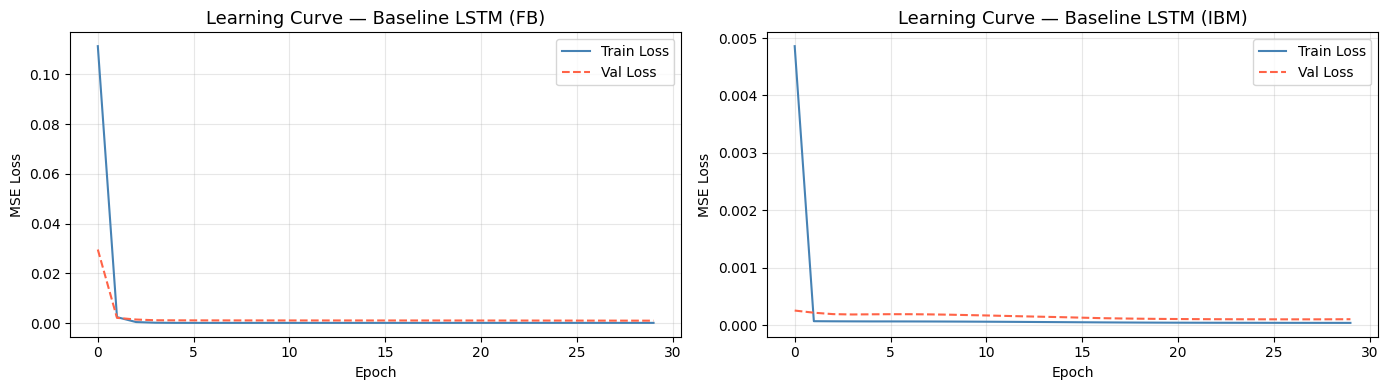

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, ticker in zip(axes, TICKERS):
    h = store[ticker]['baseline_history'].history
    ax.plot(h['loss'],     label='Train Loss', color='steelblue')
    ax.plot(h['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
    ax.set_title(f'Learning Curve — Baseline LSTM ({ticker})', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()

- Pada kedua dataset, training loss turun sangat cepat pada beberapa epoch awal, kemudian mulai stabil. Hal ini menunjukkan arsitekturnya masih sederhana (hanya satu layer LSTM) tapi berhasil mempelajari pola dasar dari data time series.
- Validation loss juga relatif stabil dan nilainya tidak jauh berbeda dengan training loss. Kondisi ini menunjukkan model memiliki kemampuan generalisasi yang cukup baik dan belum menunjukkan indikasi overfitting yang signifikan.
- Pada dataset IBM, EarlyStopping menghentikan pelatihan lebih cepat karena validation loss sudah tidak mengalami perbaikan. Sebaliknya, pada FB model tetap melanjutkan training hingga epoch terakhir karena validation loss masih cenderung stabil.

## 1c. [LO 1, LO 2, LO 3, LO 4, 15 poin] Setelah mengetahui hasil dari nomor (1c), modifikasi arsitektur pada nomor 1c untuk mendapatkan unjuk kerja yang optimal (kalian dapat menambahkan atau mengurangi arsitektur tersebut, atau mengganti hyperparameter, atau menggunakan tuning pada hyperparameter). Jelaskan alasan kalian untuk menggunakan pendekatan yang kalian pilih.


### Modifikasi
Perubahan yang dilakukan antara lain:

- Menggunakan Stacked LSTM (2 layer LSTM) agar model dapat mempelajari pola temporal yang lebih kompleks dibandingkan satu layer LSTM.
- Menambahkan Dropout (0.2) setelah setiap layer LSTM sebagai regularisasi untuk mengurangi risiko overfitting.
- Menambahkan Batch Normalization untuk menstabilkan distribusi aktivasi sehingga proses training menjadi lebih stabil.
- Menambahkan Dense layer berukuran 32 neuron sebelum layer output untuk meningkatkan kemampuan model dalam mempelajari representasi data.
- Tetap menggunakan optimizer Adam dengan learning rate 0.001 dan loss function Mean Squared Error (MSE).

In [38]:
tf.random.set_seed(42)

def build_modified():
    model = Sequential([
        LSTM(units=128, activation='relu', return_sequences=True,
             input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.2),

        LSTM(units=64, activation='relu', return_sequences=False),
        Dropout(0.2),

        BatchNormalization(),

        Dense(units=32, activation='relu'),
        Dense(units=1)
    ], name='Modified_Stacked_LSTM')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

build_modified().summary()

Model: "Modified_Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 5, 128)         │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,337 (462.25 KB)

 Trainable params: 118,209 (461.75 KB)

 Non-trainable params: 128 (512.00 B)

Arsitektur yang digunakan terdiri dari dua layer LSTM dengan masing-masing 128 dan 64 unit, dilanjutkan dengan Dropout, Batch Normalization, Dense 32 neuron, dan Dense 1 neuron sebagai output. Dibandingkan model baseline, jumlah parameter meningkat menjadi sekitar 118 ribu parameter, sehingga model memiliki kapasitas yang lebih besar untuk mempelajari pola pergerakan harga saham.

### Training Modified Model

In [39]:
EPOCHS_MOD = 100

for ticker in TICKERS:
    print(f'Modified: {ticker}')
    d = store[ticker]

    model = build_modified()
    callbacks_mod = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    ]

    history = model.fit(
        d['X_train'], d['y_train'],
        epochs          = EPOCHS_MOD,
        batch_size      = BATCH_SIZE,
        validation_data = (d['X_val'], d['y_val']),
        callbacks       = callbacks_mod,
        verbose         = 1
    )
    print(f'Training selesai pada epoch ke-{len(history.history["loss"])}')
    print()

    d['modified_model']   = model
    d['modified_history'] = history

Modified: FB
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0346 - val_loss: 0.1553 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0050 - val_loss: 0.1064 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041 - val_loss: 0.0977 - learning_rate: 0.0010
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0037 - val_loss: 0.0909 - learning_rate: 0.0010
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0034 - val_loss: 0.0819 - learning_rate: 0.0010
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0036 - val_loss: 0.0746 - learning_rate: 0.0010
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0029 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0030 - val_loss: 0.0651 - learning_rate: 0.0010
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0030 - val_loss: 0.0567 - learning_rate: 0.00

### Plot Learning Curve Modified

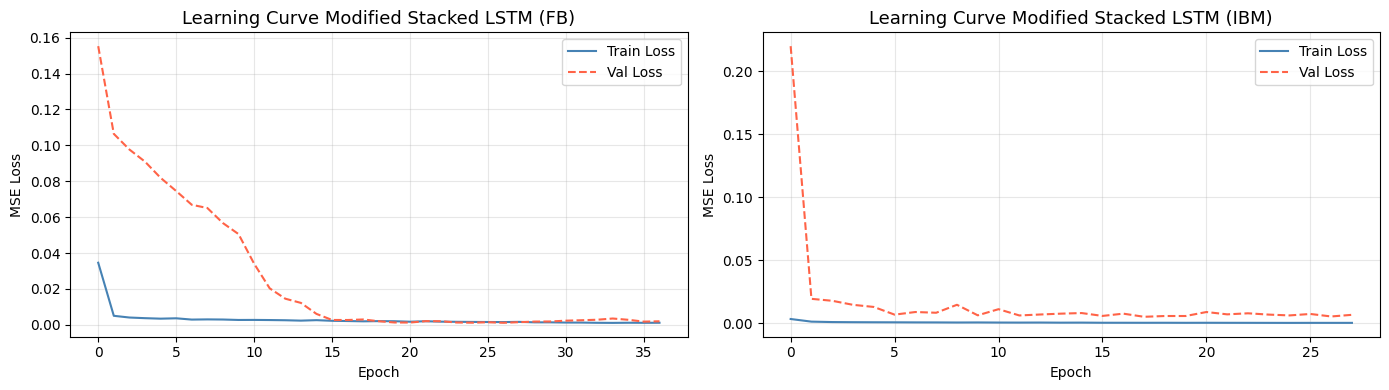

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, ticker in zip(axes, TICKERS):
    h = store[ticker]['modified_history'].history
    ax.plot(h['loss'],     label='Train Loss', color='steelblue')
    ax.plot(h['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
    ax.set_title(f'Learning Curve Modified Stacked LSTM ({ticker})', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('modified_learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()

Pada kedua dataset, training loss terus menurun hingga mencapai nilai yang kecil, menunjukkan bahwa model berhasil mempelajari pola dari data training. Validation loss pada awal training bernilai cukup tinggi, kemudian turun secara signifikan hingga mendekati training loss. Hal ini menunjukkan bahwa model semakin mampu melakukan generalisasi terhadap data yang belum pernah dilihat. Ketika validation loss mulai stagnan atau meningkat, ReduceLROnPlateau menurunkan learning rate sehingga proses optimasi menjadi lebih halus. Setelah tidak ada lagi peningkatan performa, EarlyStopping menghentikan training dan mengembalikan bobot terbaik.

## 1d. [LO 3, LO 4, 5 poin] Lakukan evaluasi unjuk kerja kedua arsitektur di atas pada test set dengan mencari nilai RMSE, MAE dan MAPE. Dan berikan penjelasan mengenai hasilnya dengan rinci.

Performa model dievaluasi menggunakan tiga metrik regresi, yaitu RMSE, MAE, dan MAPE pada data test. Sebelum menghitung metrik, hasil prediksi dikembalikan terlebih dahulu ke skala harga sebenarnya (inverse transform) sehingga nilai error dapat diinterpretasikan dalam satuan USD maupun persentase.

- RMSE (Root Mean Squared Error) mengukur rata-rata kesalahan prediksi dengan memberikan penalti lebih besar pada error yang besar.
- MAE (Mean Absolute Error) mengukur rata-rata selisih absolut antara nilai aktual dan hasil prediksi.
- MAPE (Mean Absolute Percentage Error) mengukur besar kesalahan dalam bentuk persentase sehingga memudahkan perbandingan performa antar saham yang memiliki skala harga berbeda.

In [41]:
def evaluate_model(model, X_test, y_test, scaler, model_name='Model'):
    y_pred_scaled = model.predict(X_test, verbose=0)

    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f'{model_name}')
    print(f'  RMSE : {rmse:.4f} USD')
    print(f'  MAE  : {mae:.4f} USD')
    print(f'  MAPE : {mape:.4f} %')
    print()

    return y_pred, y_true, {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

for ticker in TICKERS:
    print(f'{'='*50}')
    print(f'Hasil Evaluasi pada Test Set — {ticker}')
    print(f'{'='*50}')
    d = store[ticker]

    pred_baseline, y_true_arr, metrics_baseline = evaluate_model(
        d['baseline_model'], d['X_test'], d['y_test'], d['scaler'], f'Baseline LSTM ({ticker})')

    pred_modified, _, metrics_modified = evaluate_model(
        d['modified_model'], d['X_test'], d['y_test'], d['scaler'], f'Modified Stacked LSTM ({ticker})')

    d['pred_baseline'] = pred_baseline
    d['pred_modified'] = pred_modified
    d['y_true_arr']    = y_true_arr
    d['metrics_baseline'] = metrics_baseline
    d['metrics_modified'] = metrics_modified
    print()

Hasil Evaluasi pada Test Set — FB
Baseline LSTM (FB)
  RMSE : 5.5773 USD
  MAE  : 3.9227 USD
  MAPE : 2.1159 %

Modified Stacked LSTM (FB)
  RMSE : 9.6935 USD
  MAE  : 8.7027 USD
  MAPE : 4.5225 %


Hasil Evaluasi pada Test Set — IBM
Baseline LSTM (IBM)
  RMSE : 2.7909 USD
  MAE  : 1.8313 USD
  MAPE : 1.4035 %

Modified Stacked LSTM (IBM)
  RMSE : 12.5564 USD
  MAE  : 12.0622 USD
  MAPE : 8.7738 %




In [42]:
for ticker in TICKERS:
    d = store[ticker]
    comparison_df = pd.DataFrame({
        'Metrik'               : ['RMSE (USD)', 'MAE (USD)', 'MAPE (%)'],
        'Baseline LSTM'        : [f"{d['metrics_baseline']['RMSE']:.4f}",
                                  f"{d['metrics_baseline']['MAE']:.4f}",
                                  f"{d['metrics_baseline']['MAPE']:.4f}"],
        'Modified Stacked LSTM': [f"{d['metrics_modified']['RMSE']:.4f}",
                                  f"{d['metrics_modified']['MAE']:.4f}",
                                  f"{d['metrics_modified']['MAPE']:.4f}"],
    })
    print(f'Perbandingan Metrik — {ticker}')
    print(comparison_df.to_string(index=False))
    print()

Perbandingan Metrik — FB
    Metrik Baseline LSTM Modified Stacked LSTM
RMSE (USD)        5.5773                9.6935
 MAE (USD)        3.9227                8.7027
  MAPE (%)        2.1159                4.5225

Perbandingan Metrik — IBM
    Metrik Baseline LSTM Modified Stacked LSTM
RMSE (USD)        2.7909               12.5564
 MAE (USD)        1.8313               12.0622
  MAPE (%)        1.4035                8.7738



### Plot Prediksi vs Aktual

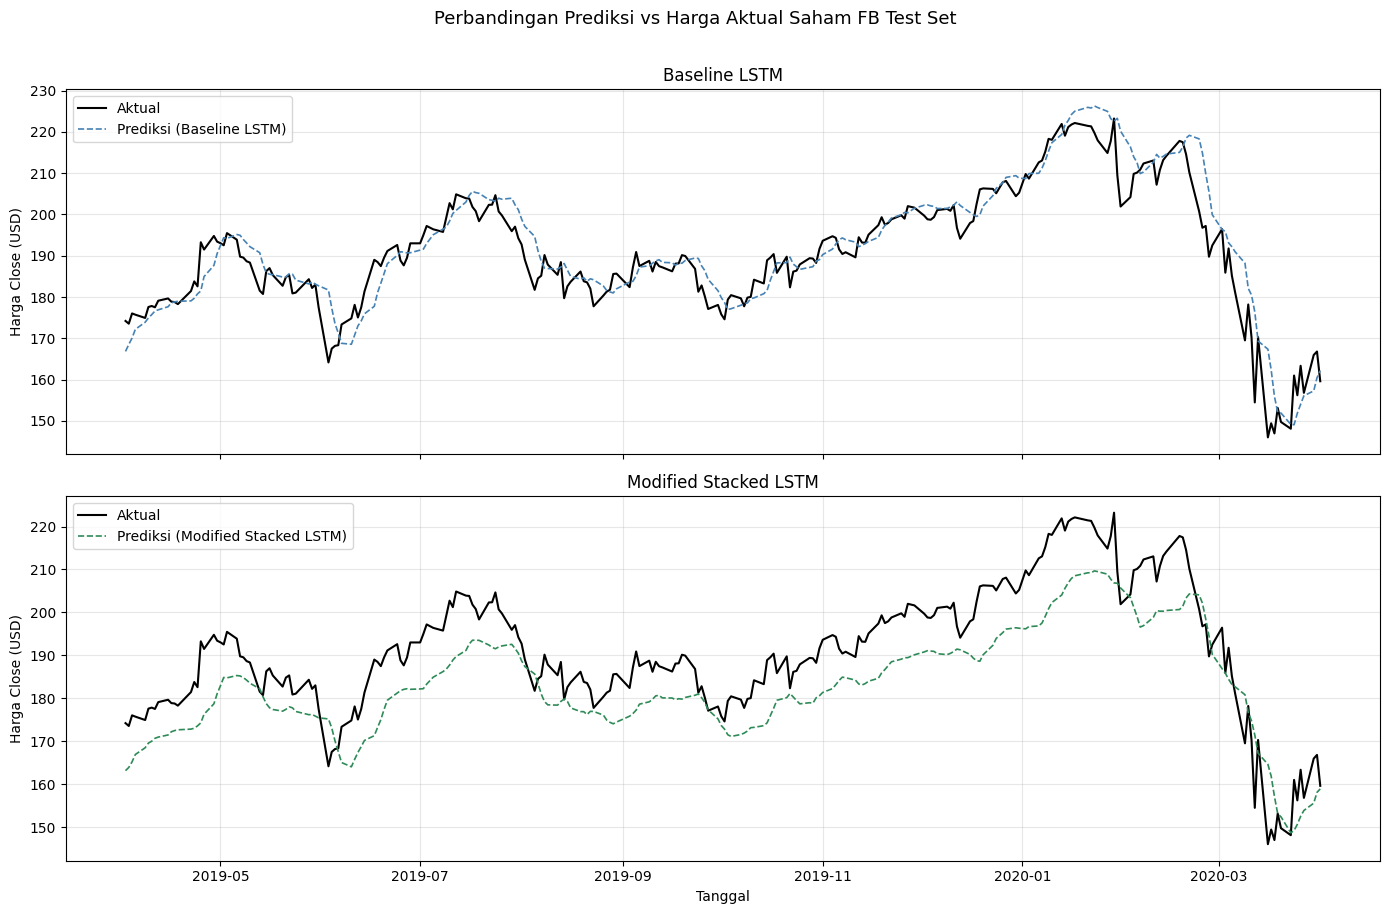

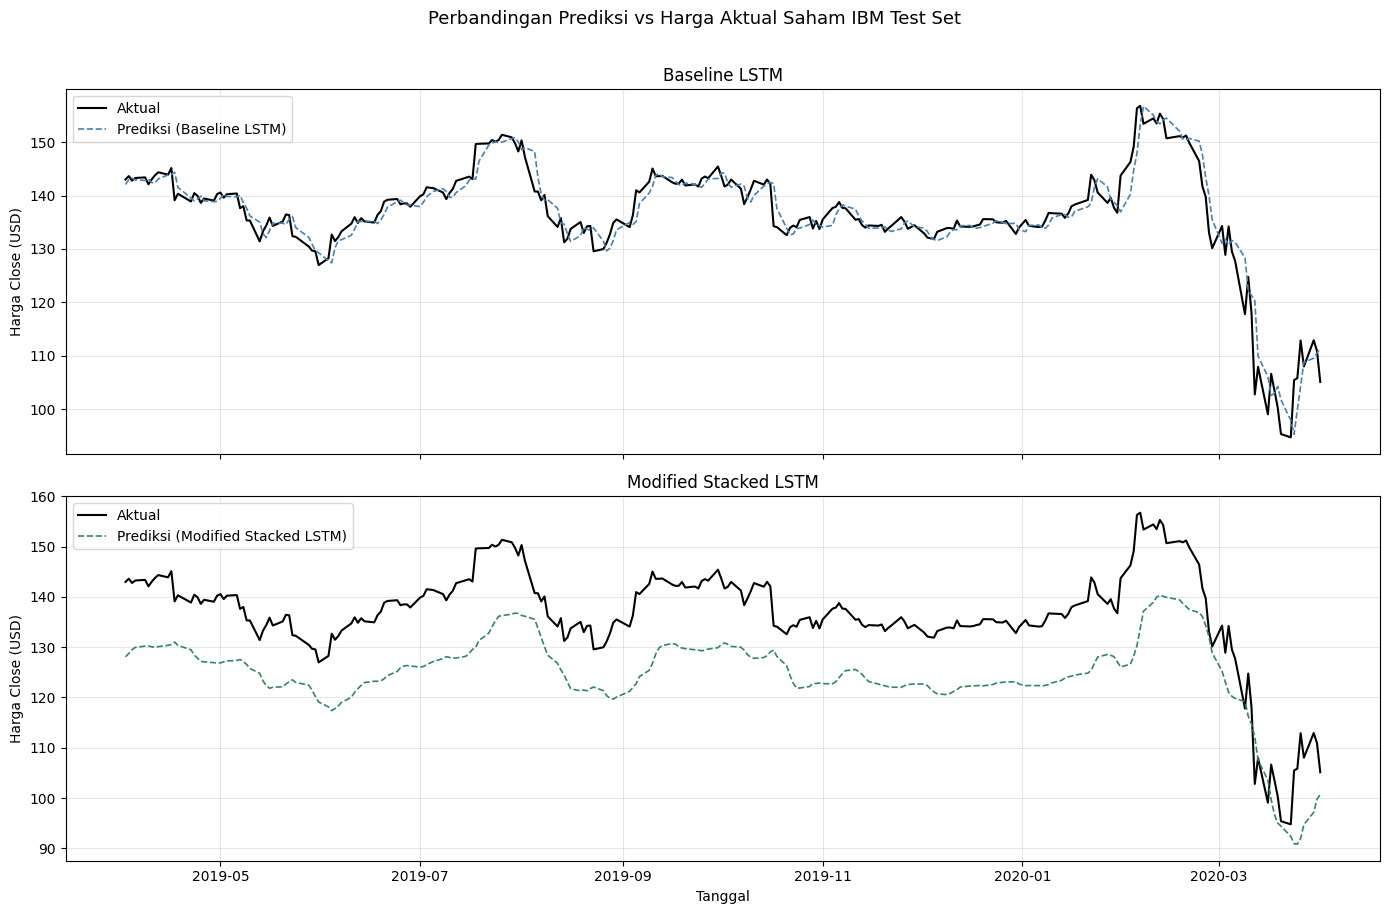

In [43]:
for ticker in TICKERS:
    d          = store[ticker]
    test_dates = d['test_df']['Date'].values[HORIZON - 1:]
    y_true_arr = d['y_true_arr']

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    for ax, pred, label, color in zip(
            axes,
            [d['pred_baseline'], d['pred_modified']],
            ['Baseline LSTM', 'Modified Stacked LSTM'],
            ['steelblue', 'seagreen']):

        n = min(len(test_dates), len(pred), len(y_true_arr))
        ax.plot(test_dates[:n], y_true_arr[:n], label='Aktual',
                color='black',  linewidth=1.5)
        ax.plot(test_dates[:n], pred[:n],
                label=f'Prediksi ({label})', color=color, linewidth=1.2, linestyle='--')
        ax.set_title(label, fontsize=12)
        ax.set_ylabel('Harga Close (USD)')
        ax.legend(loc='upper left')
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('Tanggal')
    plt.suptitle(f'Perbandingan Prediksi vs Harga Aktual Saham {ticker} Test Set',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'prediction_comparison_{ticker.lower()}.png', dpi=100, bbox_inches='tight')
    plt.show()

Pada FB, prediksi model baseline mengikuti pola harga aktual dengan cukup baik. Meskipun terdapat sedikit keterlambatan saat harga berubah cepat, arah pergerakan harga masih dapat diikuti dengan cukup akurat. Sebaliknya, model modifikasi menghasilkan kurva yang jauh lebih halus (over-smoothing), sehingga sering berada di bawah harga aktual ketika terjadi kenaikan dan terlambat mengikuti perubahan harga yang cukup tajam.

Pada IBM, kedua model sama-sama mampu mengikuti tren umum harga saham. Namun, model baseline menghasilkan kurva prediksi yang lebih dekat dengan data aktual, terutama sebelum terjadi penurunan harga yang tajam pada akhir periode pengujian. Model modifikasi kembali menghasilkan prediksi yang lebih halus sehingga beberapa perubahan harga tidak dapat diikuti secara tepat.

Selain itu, pada kedua saham terlihat bahwa seluruh model mengalami kesalahan yang lebih besar pada akhir periode test, yaitu ketika terjadi penurunan harga yang sangat tajam. Kondisi tersebut merupakan perubahan pola (distribution shift) yang cukup ekstrem dibandingkan data sebelumnya, sehingga baik model baseline maupun model modifikasi mengalami kesulitan mengikuti perubahan harga secara langsung.

## Analisis Hasil Evaluasi
Berdasarkan hasil pengujian pada test set, model baseline justru memberikan performa yang lebih baik dibandingkan model hasil modifikasi pada kedua dataset. Pada saham FB, model baseline memperoleh RMSE sebesar 5,5 USD, MAE sebesar 3,9 USD, dan MAPE sebesar 2,1%. Setelah dilakukan modifikasi arsitektur, seluruh metrik justru meningkat menjadi RMSE 9,7 USD, MAE 8,7 USD, dan MAPE 4,5%. Karena seluruh nilai error bertambah besar, dapat disimpulkan bahwa model modifikasi menghasilkan prediksi yang kurang akurat dibandingkan baseline. Hal yang sama juga terjadi pada saham IBM. Model baseline memperoleh RMSE 2,7 USD, MAE 1,8 USD, dan MAPE 1,4%, sedangkan model modifikasi menghasilkan RMSE 12.5 USD, MAE 12 USD, dan MAPE 8,7%.

## kenapa model modifikasi lebih buruk?

Walaupun arsitektur dimodifikasi menjadi lebih kompleks dengan dua layer LSTM, Dropout, Batch Normalization, dan Dense tambahan, kompleksitas model tidak selalu menghasilkan performa yang lebih baik.

- Window size yang digunakan hanya 5 hari. Informasi yang diberikan ke model relatif sedikit, sehingga arsitektur yang lebih dalam tidak memperoleh informasi tambahan yang cukup untuk dimanfaatkan. Pada kondisi ini, satu layer LSTM sudah mampu menangkap pola yang terdapat pada data.
- Jumlah parameter meningkat cukup besar. Model baseline hanya memiliki sekitar 10 ribu parameter, sedangkan model modifikasi memiliki lebih dari 118 ribu parameter. Dengan kapasitas yang jauh lebih besar, model menjadi lebih sulit dioptimalkan dan berpotensi mempelajari pola yang kurang relevan terhadap data test.
- Dropout dan Batch Normalization dapat menyebabkan model menjadi terlalu ter-regularisasi. Regularisasi memang membantu mengurangi overfitting, tetapi jika diterapkan pada model yang sebenarnya sudah cukup sederhana, kemampuan model dalam mempelajari pola data justru dapat berkurang (underfitting ringan).
- Data saham memiliki pola yang relatif sederhana pada window lima hari. Perubahan harga jangka pendek umumnya dipengaruhi oleh nilai beberapa hari sebelumnya. Oleh karena itu, model baseline yang lebih sederhana sudah cukup untuk mempelajari hubungan tersebut tanpa memerlukan arsitektur yang lebih kompleks.